Dataset Head:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Correlation Matrix:
             age       sex       bmi        bp        s1        s2        s3  \
age     1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
sex     0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
bmi     0.185085  0.08

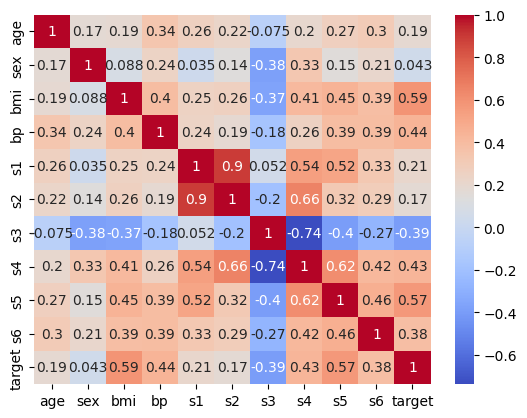

Simple Linear Regression Coefficients: [998.57768914]
Intercept: 152.00335421448167
R-squared: 0.23335039815872138
Mean Squared Error: 4061.8259284949268

Multiple Regression R-squared:  0.4526027629719195
Mean Squared Error: 2900.193628493482

Variance Inflation Factors:
  Feature        VIF
0     age   1.217307
1     sex   1.278071
2     bmi   1.509437
3      bp   1.459428
4      s1  59.202510
5      s2  39.193370
6      s3  15.402156
7      s4   8.890986
8      s5  10.075967
9      s6   1.484623


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Coefficients:
                    Feature  Coefficient
0               mean radius     2.099812
1              mean texture     0.132486
2            mean perimeter    -0.103468
3                 mean area    -0.002556
4           mean smoothness    -0.170243
5          mean compactness    -0.379844
6            mean concavity    -0.691207
7       mean concave points    -0.408107
8             mean symmetry    -0.235070
9    mean fractal dimension    -0.023564
10             radius error    -0.085405
11            texture error     1.122469
12          perimeter error    -0.325757
13               area error    -0.065194
14         smoothness error    -0.023711
15        compactness error     0.059602
16          concavity error     0.004522
17     concave points error    -0.042776
18           symmetry error    -0.041480
19  fractal dimension error     0.014251
20             worst radius     0.966303
21            worst texture    -0.377126
22          worst peri

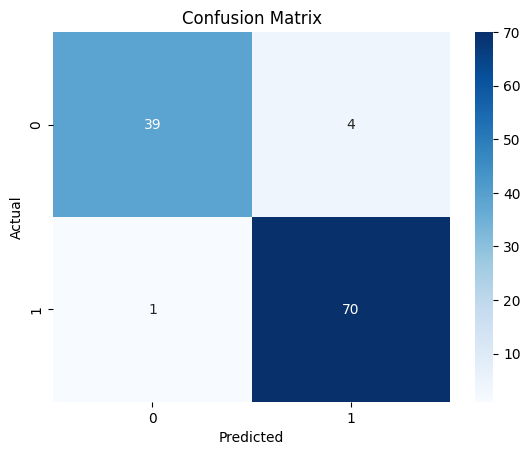

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load dataset (Example: Boston Housing Dataset for Regression, Titanic for Classification)
from sklearn.datasets import load_diabetes

data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # Target variable

# Exploratory Data Analysis (EDA)
print("Dataset Head:")
print(df.head())
print("\nCorrelation Matrix:")
print(df.corr())
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Simple Linear Regression
X = df[['bmi']] # Choosing one feature for simple regression
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

print("Simple Linear Regression Coefficients:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)
print("R-squared:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Multiple Linear Regression
X = df.drop(columns=['target']) # Using all features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_reg = LinearRegression()
multi_reg.fit(X_train, y_train)
y_pred_multi = multi_reg.predict(X_test)

print("\nMultiple Regression R-squared: ", r2_score(y_test, y_pred_multi))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_multi))

# Checking for Multicollinearity (VIF)
X_with_const = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i + 1) for i in range(len(X.columns))]
print("\nVariance Inflation Factors:")
print(vif_data)

# Logistic Regression (Using a binary classification example)
from sklearn.datasets import load_breast_cancer
data= load_breast_cancer()
df_class = pd.DataFrame(data.data, columns=data.feature_names)
df_class['target'] = data.target # Target variable (Binary: 0 or 1)
X = df_class.drop(columns=['target'])
y = df_class['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_class = log_reg.predict(X_test)

# Logit Equation Interpretation
print("\nLogistic Regression Coefficients:")
print(pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]}))

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred_class)
precision= precision_score(y_test, y_pred_class)
recall= recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)
roc_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])

print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1 :.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
